# Dataset — reading and inspecting a raster

The `Dataset` class is pyramids' wrapper around a single raster (here a multi-band GeoTIFF). This tutorial loads a NOAH
daily-precipitation file and walks through the properties every raster carries: its grid dimensions, coordinate
reference system, longitude/latitude axes, bounding box, and geotransform. By the end you will know how to open a raster
and interrogate its spatial metadata.

<p align="center">
        <img src="../../_images/schemes/dataset-attributes.png" alt= "dataset prperties" width=300 height=900>
</p>

## Setup

Import the `Dataset` class and point at the sample raster. The path is written relative to this notebook so the example
runs from a fresh checkout. Reading the file emits a one-time log line as pyramids configures GDAL.

In [1]:
# NBVAL_IGNORE_OUTPUT
from pyramids.dataset import Dataset

%matplotlib inline

path = r"../../../examples/data/geotiff/noah-precipitation-1979.tif"

2026-07-01 17:23:04 | INFO | pyramids.base.config | Logging is configured.


## Read any raster format

`Dataset.read_file` auto-detects the driver from the file and returns a `Dataset`. The same call works for GeoTIFF,
NetCDF, and any other format GDAL can open — you don't pick a reader per format.

In [2]:
dataset = Dataset.read_file(path)

## Explore the dataset

Printing a `Dataset` gives a compact summary of its geo-metadata: corner coordinates, cell size, grid shape, CRS, band
list, no-data mask, and dtype. It's the quickest way to sanity-check a file after loading it.

In [3]:
print(dataset)


            Top Left Corner: (0.0, 90.0)
            Cell size: 0.5
            Dimension: 360 * 720
            EPSG: 4326
            Number of Bands: 4
            Band names: ['Band_1', 'Band_2', 'Band_3', 'Band_4']
            Band colors: {0: 'gray_index', 1: 'undefined', 2: 'undefined', 3: 'undefined'}
            Band units: ['', '', '', '']
            Scale: [1.0, 1.0, 1.0, 1.0]
            Offset: [0, 0, 0, 0]
            Mask: -9.969209968386869e+36
            Data type: float32
            File: ../../../examples/data/geotiff/noah-precipitation-1979.tif
        


The summary confirms a global 0.5-degree grid (360 rows x 720 columns), 4 bands, EPSG:4326, and a `float32` no-data mask
around -9.97e+36. The four bands are the first four daily precipitation fields of 1979.

## Plot a band

`Dataset.plot` renders one band through cleopatra and returns an `ArrayGlyph` (its matplotlib handles live on `.fig` /
`.ax` if you need to tweak them). The key options:

| parameter | meaning | typical value |
| --- | --- | --- |
| `band` | which band to draw (0-based) | `0` |
| `vmax` | upper clip for the colour scale | `30` (mm/day) |
| `cbar_label` | colour-bar caption | `"Rainfall mm/day"` |
| `cbar_length` | colour-bar length as a fraction of the axis | `0.85` |
| `figsize` | figure size in inches | `(10, 5)` |

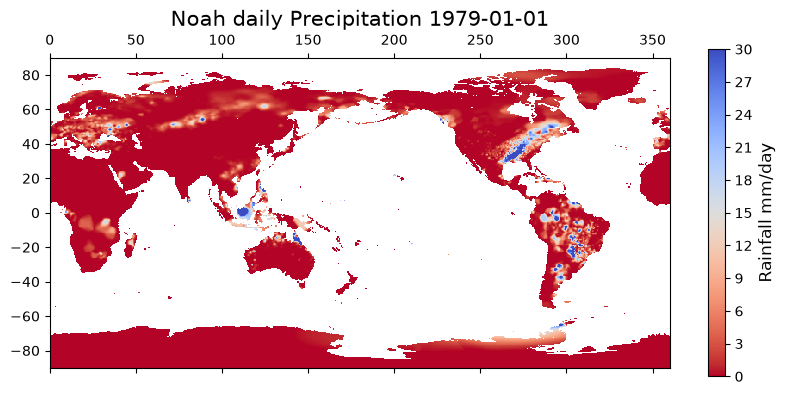

In [4]:
array_glyph = dataset.plot(
    band=0,
    figsize=(10, 5),
    title="Noah daily Precipitation 1979-01-01",
    cbar_label="Rainfall mm/day",
    vmax=30,
    cbar_length=0.85,
)

The map shows the first day's precipitation on a global grid. Because this file uses a 0-360 longitude axis, the layout
is centered on the antimeridian — see the companion `convert-longitude` notebook for the fix.

## Grid dimensions

A raster is a cube of `(bands, rows, columns)`. These properties expose each axis separately so you can size arrays or
loop over bands without touching GDAL directly.

In [5]:
print(f"Dataset dimensions: {dataset.shape}")
print(f"Dataset rows: {dataset.rows}")
print(f"Dataset columns: {dataset.columns}")
print(f"Dataset number of bands: {dataset.band_count}")

Dataset dimensions: (4, 360, 720)
Dataset rows: 360
Dataset columns: 720
Dataset number of bands: 4


`shape` is `(4, 360, 720)` — 4 bands over a 360x720 grid — and `band_count` is 4, matching the four daily fields seen in
the summary.

### Cell size

The cell size is the ground resolution of one pixel, in the CRS units (degrees here). 0.5 means each pixel is half a
degree on a side.

In [6]:
print(f"Cell size: {dataset.cell_size}")

Cell size: 0.5


### Band names

Each band carries a name. NOAH daily fields import with generic `Band_1 ... Band_4` labels, which you can use to select
or relabel bands.

In [7]:
dataset.band_names

['Band_1', 'Band_2', 'Band_3', 'Band_4']

## Spatial reference

The CRS ties the pixel grid to real-world coordinates. `epsg` is the numeric code (4326 = WGS84 lon/lat) and `crs` is
the full WKT definition.

In [8]:
print(f"EPSG: {dataset.epsg}")
print(f"Coordinate reference system: {dataset.crs}")

EPSG: 4326
Coordinate reference system: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


EPSG 4326 is geographic WGS84, so coordinates are in degrees of longitude/latitude. The next two properties give the
coordinate of each column (`lon`) and each row (`lat`).

In [9]:
dataset.lon

array([2.5000e-01, 7.5000e-01, 1.2500e+00, 1.7500e+00, 2.2500e+00,
       2.7500e+00, 3.2500e+00, 3.7500e+00, 4.2500e+00, 4.7500e+00,
       5.2500e+00, 5.7500e+00, 6.2500e+00, 6.7500e+00, 7.2500e+00,
       7.7500e+00, 8.2500e+00, 8.7500e+00, 9.2500e+00, 9.7500e+00,
       1.0250e+01, 1.0750e+01, 1.1250e+01, 1.1750e+01, 1.2250e+01,
       1.2750e+01, 1.3250e+01, 1.3750e+01, 1.4250e+01, 1.4750e+01,
       1.5250e+01, 1.5750e+01, 1.6250e+01, 1.6750e+01, 1.7250e+01,
       1.7750e+01, 1.8250e+01, 1.8750e+01, 1.9250e+01, 1.9750e+01,
       2.0250e+01, 2.0750e+01, 2.1250e+01, 2.1750e+01, 2.2250e+01,
       2.2750e+01, 2.3250e+01, 2.3750e+01, 2.4250e+01, 2.4750e+01,
       2.5250e+01, 2.5750e+01, 2.6250e+01, 2.6750e+01, 2.7250e+01,
       2.7750e+01, 2.8250e+01, 2.8750e+01, 2.9250e+01, 2.9750e+01,
       3.0250e+01, 3.0750e+01, 3.1250e+01, 3.1750e+01, 3.2250e+01,
       3.2750e+01, 3.3250e+01, 3.3750e+01, 3.4250e+01, 3.4750e+01,
       3.5250e+01, 3.5750e+01, 3.6250e+01, 3.6750e+01, 3.7250e

`lat` is the matching per-row latitude axis. It runs from +89.75 down to -89.75 because raster rows are ordered
north-to-south (top-left origin).

In [10]:
dataset.lat

array([ 89.75,  89.25,  88.75,  88.25,  87.75,  87.25,  86.75,  86.25,
        85.75,  85.25,  84.75,  84.25,  83.75,  83.25,  82.75,  82.25,
        81.75,  81.25,  80.75,  80.25,  79.75,  79.25,  78.75,  78.25,
        77.75,  77.25,  76.75,  76.25,  75.75,  75.25,  74.75,  74.25,
        73.75,  73.25,  72.75,  72.25,  71.75,  71.25,  70.75,  70.25,
        69.75,  69.25,  68.75,  68.25,  67.75,  67.25,  66.75,  66.25,
        65.75,  65.25,  64.75,  64.25,  63.75,  63.25,  62.75,  62.25,
        61.75,  61.25,  60.75,  60.25,  59.75,  59.25,  58.75,  58.25,
        57.75,  57.25,  56.75,  56.25,  55.75,  55.25,  54.75,  54.25,
        53.75,  53.25,  52.75,  52.25,  51.75,  51.25,  50.75,  50.25,
        49.75,  49.25,  48.75,  48.25,  47.75,  47.25,  46.75,  46.25,
        45.75,  45.25,  44.75,  44.25,  43.75,  43.25,  42.75,  42.25,
        41.75,  41.25,  40.75,  40.25,  39.75,  39.25,  38.75,  38.25,
        37.75,  37.25,  36.75,  36.25,  35.75,  35.25,  34.75,  34.25,
      

## Bounding box and bounds

`bbox` returns the extent as a plain `[xmin, ymin, xmax, ymax]` list, while `bounds` returns it as a GeoDataFrame polygon
you can plot or intersect with other vector layers.

In [11]:
dataset.bbox

[0.0, -90.0, 360.0, 90.0]

`bounds` wraps the same extent as a one-row GeoDataFrame, so the footprint can be treated as vector geometry.

In [12]:
print(dataset.bounds)

                                         geometry
0  POLYGON ((0 90, 0 -90, 360 -90, 360 90, 0 90))


Because `bounds` is a GeoDataFrame, its `.plot()` draws the raster footprint as a rectangle.

<Axes: >

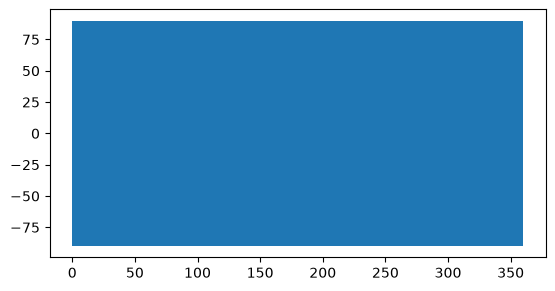

In [13]:
dataset.bounds.plot()

The rectangle is the raster's ground footprint — here the full globe (0..360 lon, -90..90 lat) in the file's native
coordinates.

### Geotransform

The GDAL geotransform is the six-number affine mapping from pixel (col, row) to world (x, y):
`(x_origin, pixel_width, 0, y_origin, 0, pixel_height)`. A negative pixel height means rows run north-to-south.

In [14]:
dataset.geotransform

(0.0, 0.5, 0.0, 90.0, 0.0, -0.5)

### Top-left corner

`top_left_corner` is the world coordinate of the grid's origin — surfaced as a convenient tuple from the geotransform.

In [15]:
dataset.top_left_corner

(0.0, 90.0)